# Screening for a winter proof portfolio

In [1]:
from fins.terminal import *
from datetime import date, datetime

filename_candidates_raw = "candidates_raw.Basket"
Delete(filename_candidates_raw)
candidates = Get(filename_candidates_raw)
if not candidates:
    candidates = Screen(mcap_min = 2 * Billion, limit=5000)(Mcap().min(1 * Billion)).basket()
    print(f"Candidates for further screening: {len(candidates)}")
    candidates((Inception().max(datetime.fromisoformat("2015-01-01"))) >> Update(older_than="2025-06-01") >> Alive().true()).basket()
    Put(candidates, "candidates_raw")


Deleted: /candidates_raw.Basket
Entity not found: /candidates_raw.Basket
Creating basket from 4434 tickers
Fetching symbols 4434 items...
Completed 4434/4434 in 7s (567.8/s)s left
Plugin: Inception(alias=None)
Computing Inception 4434 items...
Completed 4434/4434 in 0s (9385.8/s)eft
Finished pipeline - final basket has 4425 items
Plugin: Mcap(alias=None)
Computing MCap 4425 items...
Completed 4425/4425 in 0s (9016.1/s)eft
Finished pipeline - final basket has 4391 items
Candidates for further screening: 4391
Plugin: Inception(alias=None)
Computing Inception 4391 items...
Completed 4391/4391 in 0s (8727.4/s)s left
Plugin: Update(alias=None, older_than='2025-06-01', max=100)
Checking 3214 symbols for update requirement
0 symbols need updating, updating 0 of them according to max_updates
No symbols need updating
Plugin: Alive(alias=None)
Computing Alive 3214 items...
Completed 3214/3214 in 20s (155.3/s)s left
Finished pipeline - final basket has 3059 items
Saved Basket: /candidates_raw.Bas

In [2]:
cagr_2021_post_covid = Cagr(date_from="2021-11-22", date_to="2022-12-05")
cagr_2018_sell_off = Cagr(date_from="2018-10-01", date_to="2018-12-31")
cagr_2015_drawdown = Cagr(date_from="2015-06-22", date_to="2015-08-29")
cagr_2008_bfc = Cagr(date_from="2007-10-15", date_to="2009-01-26")

good_in_2021 = candidates(Alive().true() >> Inception() >> cagr_2021_post_covid.min(0) >> Cagr(date_from="2015-01-01").min(0.05))
good_in_2021.df()

Plugin: Alive(alias=None)
Computing Alive 4391 items...
Completed 4391/4391 in 4s (885.5/s)s leftt
Plugin: Inception(alias=None)
Computing Inception 4035 items...
Completed 4035/4035 in 0s (9540.0/s)eft
Plugin: Cagr(alias=None, date_from='2021-11-22', date_to='2022-12-05', year=None, resolution='m')
Computing CAGR[21-11-22;22-12-05] 4035 items...
654/4035 (216.6/s) - 3s elapsed, 15s left

Exception: Failed to compute CAGR[21-11-22;22-12-05] for CRCL: No data found for symbol

In [23]:
THRO.symbol().get_weekly()

,date,open,high,low,avg,close
0,2010-04-11,1.00,1.00,1.00000,1.000000,1.00000
1,2010-04-18,1.00,1.00,1.00000,1.000000,1.00000
2,2010-04-25,1.00,1.00,1.00000,1.000000,1.00000
3,2010-05-02,1.00,1.00,1.00000,1.000000,1.00000
4,2010-05-09,1.00,1.00,0.90441,0.952205,0.90441
...,...,...,...,...,...,...
789,2025-05-25,33.87,34.38,33.18000,33.722500,33.46000
790,2025-06-01,33.93,34.29,33.67000,33.987500,34.06000
791,2025-06-08,33.97,34.73,33.79000,34.285000,34.65000
792,2025-06-15,34.68,34.70,34.10000,34.417500,34.19000


Cropping 2 symbols to common date range...
Common date range: 1980-12-14 to 2025-06-22
Cropped 2 time series to common range


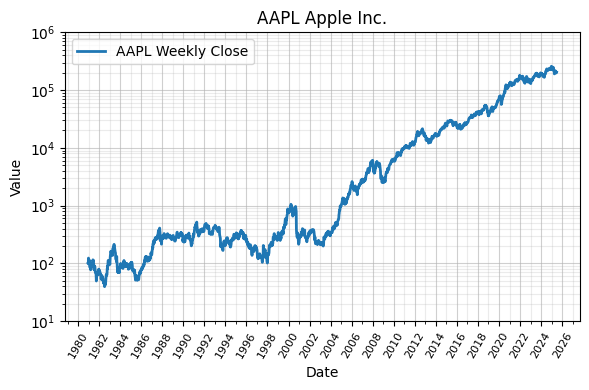

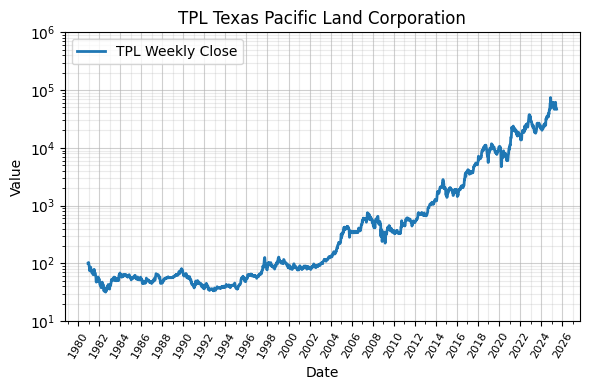

,ticker,weight,Name,Industry,Sector,CAGR[2014],CAGR[2015],CAGR[2016],CAGR[2017],CAGR[2018],CAGR[2019],CAGR[2020],CAGR[2021],CAGR[2022]
0,AAPL,1,Apple Inc.,Consumer Electronics,Technology,0.588918,0.092256,0.109128,0.548022,0.110323,0.845475,0.724206,0.289816,-0.175515
1,TPL,1,Texas Pacific Land Corporation,Oil & Gas Exploration & Production,Energy,0.513829,0.318487,1.608014,0.404889,0.382072,0.310584,-0.217471,0.819386,1.278332
